# Crypto and Stablecoin Liquidity Pulse

This notebook uses public crypto-market and DeFi liquidity data to describe recent market structure.

Sources:

- CoinGecko market chart for BTC/ETH price history;
- DeFiLlama stablecoin data for liquidity context.

Data sources are recorded in the source audit table.


In [1]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from examples.hot_trends.data import (
    HotTrendDataError,
    append_real_snapshot,
    build_arxiv_monthly_counts,
    fetch_coingecko_market_chart,
    fetch_defillama_stablecoin_chains,
    fetch_github_repo_metadata,
    fetch_github_stargazers,
    fetch_huggingface_models,
    fetch_wikipedia_pageviews,
    source_audit_table,
)
from examples.hot_trends.decomposition import (
    component_summary,
    decompose_table,
    editorial_priority,
    residual_event_table,
)
from examples.hot_trends.scoring import article_publication_phrasing

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)
plt.rcParams.update({"axes.grid": True})

CACHE_DIR = Path("examples/hot_trends/cache")
OUTPUT_DIR = Path("examples/hot_trends/outputs")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def save_table(df, name):
    path = OUTPUT_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    print(f"saved: {path.as_posix()}")


## 1. Fetch real BTC and ETH market charts


In [2]:
coins = ["bitcoin", "ethereum"]
frames = [fetch_coingecko_market_chart(c, days=365) for c in coins]
prices = pd.concat(frames, ignore_index=True)
prices.head(20)


,date,coin_id,price,source,data_quality
0,2025-05-23,bitcoin,111560.356938,CoinGecko API,public_api_snapshot
1,2025-05-24,bitcoin,107216.668569,CoinGecko API,public_api_snapshot
2,2025-05-25,bitcoin,107831.363744,CoinGecko API,public_api_snapshot
3,2025-05-26,bitcoin,108861.810377,CoinGecko API,public_api_snapshot
4,2025-05-27,bitcoin,109377.715133,CoinGecko API,public_api_snapshot
5,2025-05-28,bitcoin,109068.456949,CoinGecko API,public_api_snapshot
6,2025-05-29,bitcoin,107838.184311,CoinGecko API,public_api_snapshot
7,2025-05-30,bitcoin,105745.416604,CoinGecko API,public_api_snapshot
8,2025-05-31,bitcoin,104010.919562,CoinGecko API,public_api_snapshot
9,2025-06-01,bitcoin,104687.507429,CoinGecko API,public_api_snapshot


## 2. Audit real price table


In [3]:
audit = source_audit_table(prices, value_col="price", entity_col="coin_id", time_col="date")
audit


,series,first_timestamp,last_timestamp,observations,missing_ratio,min_value,max_value
0,bitcoin,2025-05-23 00:00:00,2026-05-22 00:00:00,366,0.0,62853.690384,124773.508231
1,ethereum,2025-05-23 00:00:00,2026-05-22 00:00:00,366,0.0,1820.569322,4829.225542


## 3. Decompose crypto price series


In [4]:
components = decompose_table(prices, entity_col="coin_id", time_col="date", value_col="price", method="MA_BASELINE", period=7, trend_window=21, transform="log")
summary = editorial_priority(component_summary(components, entity_col="coin_id", time_col="date"), entity_col="coin_id")
summary


,coin_id,observations,first_timestamp,last_timestamp,trend_last,trend_slope_per_step,cycle_strength_proxy,residual_std,max_abs_residual_z,method,trend_slope_per_step_rank_pct,cycle_strength_proxy_rank_pct,max_abs_residual_z_rank_pct,editorial_priority_score
1,ethereum,366,2025-05-23 00:00:00,2026-05-22 00:00:00,4.025442,-0.001398,-2.727087,0.523240,64.191978,MA_BASELINE,1.0,1.0,0.5,0.775
0,bitcoin,366,2025-05-23 00:00:00,2026-05-22 00:00:00,5.901926,-0.001547,-14.437076,0.770724,125.712740,MA_BASELINE,0.5,0.5,1.0,0.725


## Visualization: crypto price components

BTC and ETH are plotted as transformed price components so trend and residual shocks are visible.

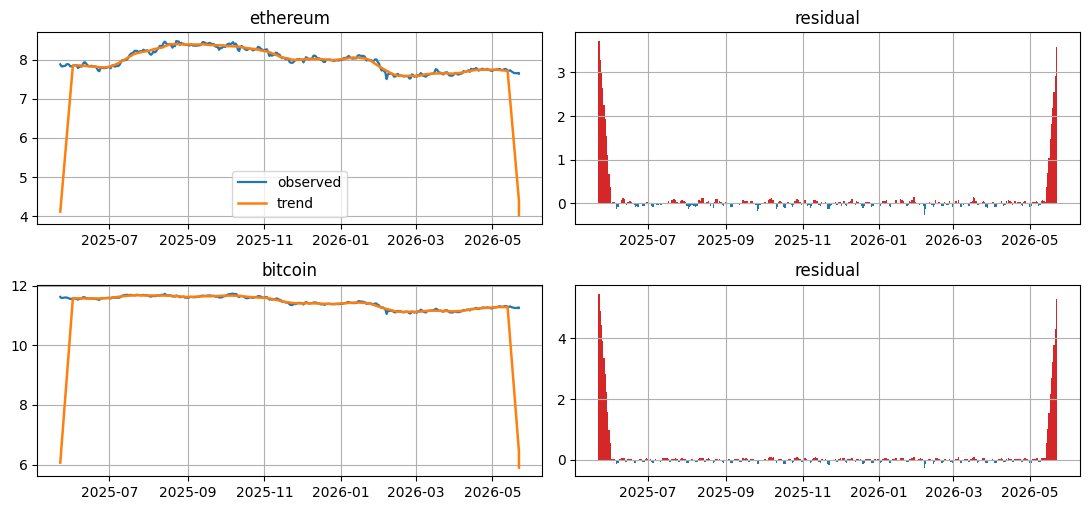

In [5]:
coins_to_plot = summary["coin_id"].tolist()
fig, axes = plt.subplots(len(coins_to_plot), 2, figsize=(11, max(3.0, 2.6 * len(coins_to_plot))), squeeze=False)
for row, coin_id in enumerate(coins_to_plot):
    panel = components.loc[components["coin_id"].eq(coin_id)].sort_values("date").copy()
    panel["date"] = pd.to_datetime(panel["date"])
    axes[row, 0].plot(panel["date"], panel["observed"], label="observed", linewidth=1.6)
    axes[row, 0].plot(panel["date"], panel["trend"], label="trend", linewidth=1.8)
    axes[row, 0].set_title(coin_id)
    axes[row, 1].bar(panel["date"], panel["residual"], color=np.where(panel["residual"] >= 0, "tab:red", "tab:blue"), width=1.0)
    axes[row, 1].set_title("residual")
axes[0, 0].legend(loc="best")
plt.tight_layout()
plt.show()


## 4. Residual events


In [6]:
events = residual_event_table(components, entity_col="coin_id", time_col="date", top_n=20)
events


,date,coin_id,observed,trend,season,residual,residual_z,abs_residual_z,method
0,2025-05-23,bitcoin,11.622321,6.068095,0.080769,5.473457,125.712740,125.712740,MA_BASELINE
1,2026-05-22,bitcoin,11.258631,5.901926,0.079347,5.277358,121.189134,121.189134,MA_BASELINE
2,2025-05-24,bitcoin,11.582607,6.619053,0.079347,4.884207,112.119937,112.119937,MA_BASELINE
3,2026-05-22,bitcoin,11.243608,6.440551,0.080769,4.722288,108.384780,108.384780,MA_BASELINE
4,2025-05-25,bitcoin,11.588324,7.169807,-0.031227,4.449744,102.097739,102.097739,MA_BASELINE
5,2026-05-21,bitcoin,11.257516,6.979420,-0.022145,4.300241,98.649005,98.649005,MA_BASELINE
6,2025-05-26,bitcoin,11.597835,7.720280,-0.039315,3.916869,89.805382,89.805382,MA_BASELINE
7,2026-05-20,bitcoin,11.249075,7.517430,-0.036103,3.767747,86.365433,86.365433,MA_BASELINE
8,2025-05-27,bitcoin,11.602562,8.269294,-0.034406,3.367674,77.136548,77.136548,MA_BASELINE
9,2026-05-19,bitcoin,11.250940,8.055151,-0.034406,3.230195,73.965169,73.965169,MA_BASELINE


## 5. Fetch stablecoin context from DeFiLlama

This cell reads the DeFiLlama stablecoin endpoint schema and records the table used for the liquidity summary.


In [7]:
stable_chains = fetch_defillama_stablecoin_chains()
stable_chains.head(20)


,totalCirculatingUSD,name
0,{'peggedUSD': 7237463.781202499},Manta
1,{'peggedUSD': 475476.28307619924},ThunderCore
2,{'peggedUSD': 39708803.407568865},Movement
3,{'peggedUSD': 32708.273900759646},Shiden
4,{'peggedUSD': 138881.13092658969},Corn
5,{'peggedUSD': 345654711.1928391},Starknet
6,"{'peggedUSD': 90335688671.02623, 'peggedREAL':...",Tron
7,{'peggedUSD': 3535202.247888792},CORE
8,{'peggedUSD': 317388.2763332},ApeChain
9,"{'peggedUSD': 3777058.8377104434, 'peggedSGD':...",Zilliqa


## Visualization: stablecoin chain context

The DeFiLlama context chart adds liquidity scale around the BTC/ETH residual events.

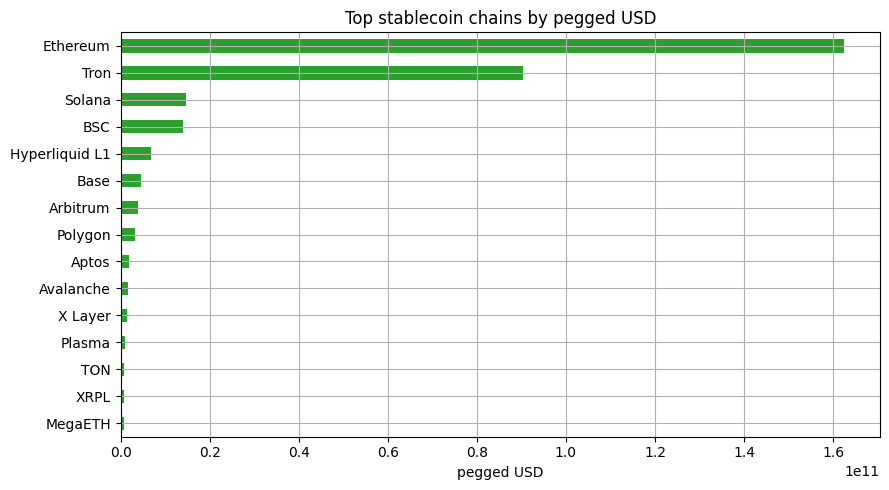

In [8]:
def _pegged_usd(value):
    if isinstance(value, dict):
        return float(value.get("peggedUSD") or 0.0)
    return float(value or 0.0)

stable_context = stable_chains.assign(pegged_usd=stable_chains["totalCirculatingUSD"].map(_pegged_usd))
stable_context = stable_context.sort_values("pegged_usd", ascending=False).head(15).sort_values("pegged_usd")
ax = stable_context.plot(kind="barh", x="name", y="pegged_usd", figsize=(9, 5), color="tab:green", legend=False, title="Top stablecoin chains by pegged USD")
ax.set_xlabel("pegged USD")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## 6. Publication phrasing


In [9]:
phrasing = article_publication_phrasing()
phrasing


,draft_claim,evidence_based_phrasing
0,This trend predicts the next price move.,This trend summarizes the observed public seri...
1,This model is better because it has more downl...,Downloads are a public adoption proxy and shou...
2,This repo is winning because stars are rising.,"Star velocity measures developer attention, no..."
3,This pageview spike proves importance.,Pageviews measure public attention during the ...
4,This residual is a buy signal.,This residual marks an event-like deviation fr...


In [10]:
save_table(audit, "06_crypto_price_audit")
save_table(summary, "06_crypto_price_summary")
save_table(events, "06_crypto_price_residual_events")
save_table(stable_chains, "06_defillama_stablecoin_context")
save_table(phrasing, "06_crypto_publication_phrasing")


saved: examples/hot_trends/outputs/06_crypto_price_audit.csv
saved: examples/hot_trends/outputs/06_crypto_price_summary.csv
saved: examples/hot_trends/outputs/06_crypto_price_residual_events.csv
saved: examples/hot_trends/outputs/06_defillama_stablecoin_context.csv
saved: examples/hot_trends/outputs/06_crypto_publication_phrasing.csv
